In [1]:
from mlxtend.classifier import OneRClassifier
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("../data/train_clear.csv")

In [3]:
target = "Liver_Disease_Type"
X = df.drop(columns=[target])
y = df[target]

In [4]:
X_encoded = pd.get_dummies(X).astype(int)

In [5]:
le = LabelEncoder()
y_encoded = np.array(le.fit_transform(y))

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
selected_features = []

In [7]:
all_y_true = []
all_y_pred = []

In [8]:
for fold, (train_index, val_index) in enumerate(skf.split(X_encoded, y_encoded)):
    X_train, X_val = X_encoded.iloc[train_index], X_encoded.iloc[val_index]
    y_train, y_val = y_encoded[train_index], y_encoded[val_index]
    
    model = OneRClassifier()
    model.fit(X_train.to_numpy(), y_train)

    y_pred = model.predict(X_val.to_numpy())
    
    score = model.score(X_val.to_numpy(), y_val)
    cv_scores.append(score)

    all_y_true.extend(y_val)
    all_y_pred.extend(y_pred)
    
    winning_feature = X_train.columns[model.feature_idx_]
    selected_features.append(winning_feature)

In [9]:
scores = np.array(cv_scores)

In [10]:
f"Точность One Rule Classifier: {scores.mean():0.3f} ± {scores.std():0.3f}"

'Точность One Rule Classifier: 0.513 ± 0.001'

In [11]:
selected_features

['ALT', 'ALT', 'ALT', 'ALT', 'ALT']

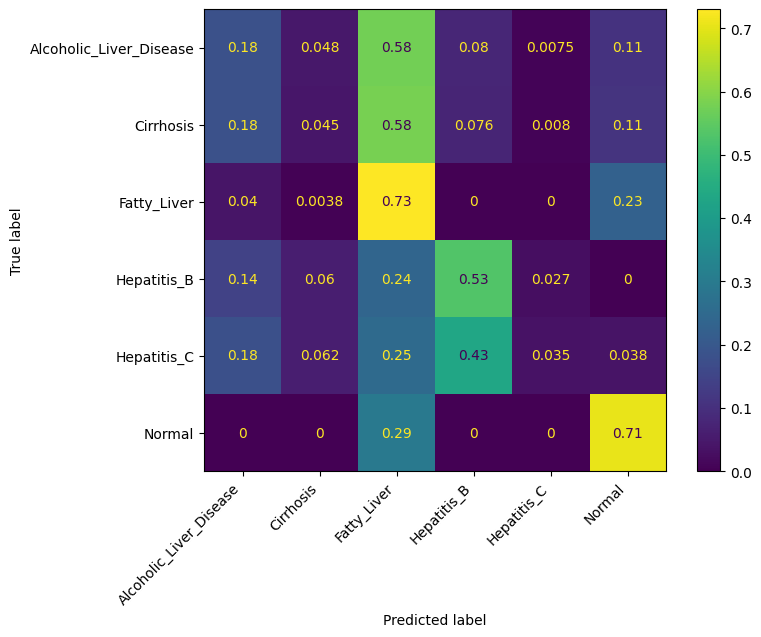

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
disp_raw = ConfusionMatrixDisplay.from_predictions(
    all_y_true, 
    all_y_pred, 
    display_labels=le.classes_,
    ax=ax,
    normalize="true"
)
plt.xticks(rotation=45, ha='right')
plt.show()